Training Spiral with Unregularized (penalty=0.0)...
>> Unregularized Results | Test Accuracy: 84.00%


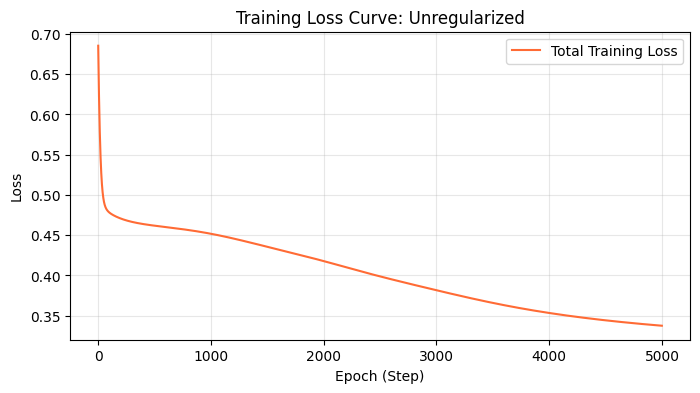

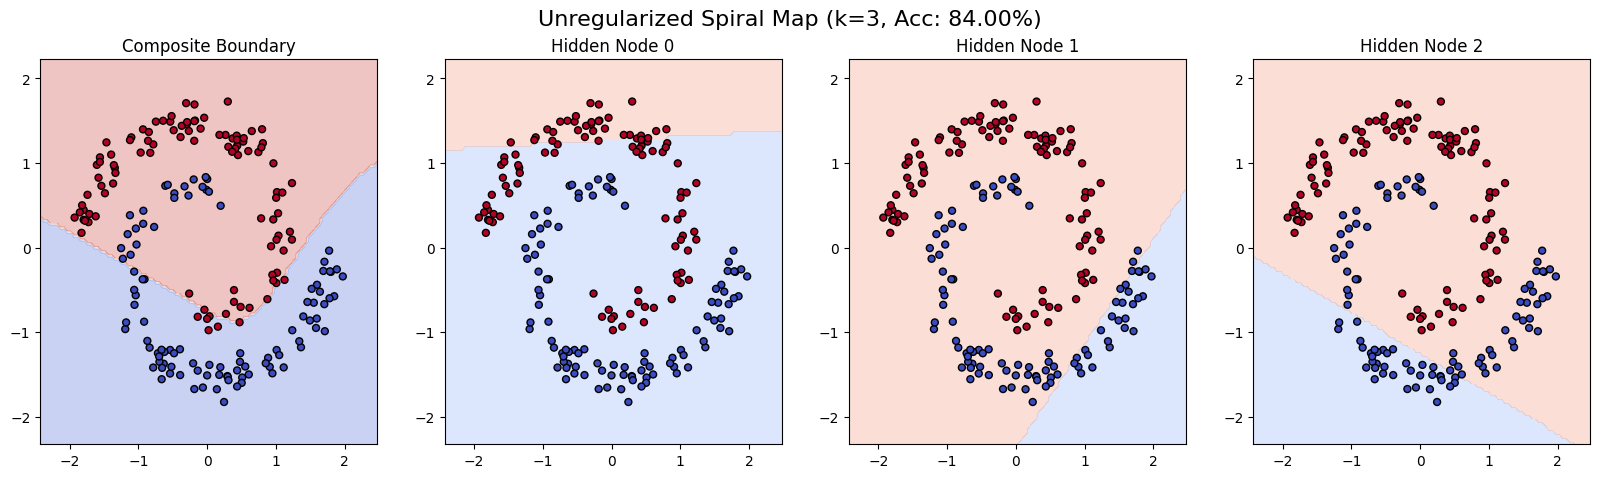

------------------------------
HYPERPARAMETERS (Unregularized)
------------------------------
Dataset             : Spiral
Learning Rate       : 0.1
Epochs              : 5000
Hidden Nodes (k)    : 3
Orthogonality Lambda: 0.0
Optimizer           : Gradient Descent
Loss                : Multi-class(2 classes) CrossEntropy + Penalty
------------------------------

Training Spiral with Regularized (penalty=0.01)...
>> Regularized Results | Test Accuracy: 88.50%


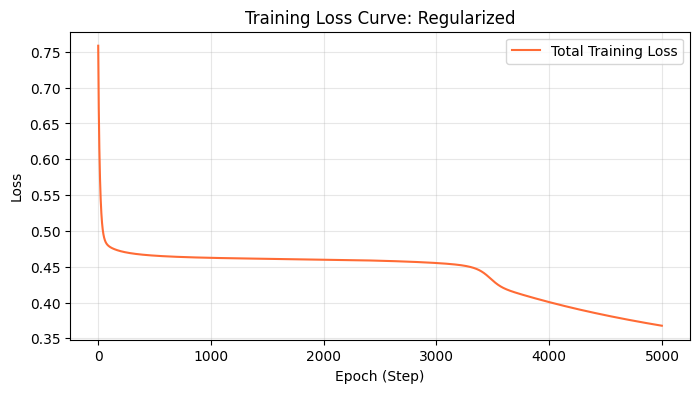

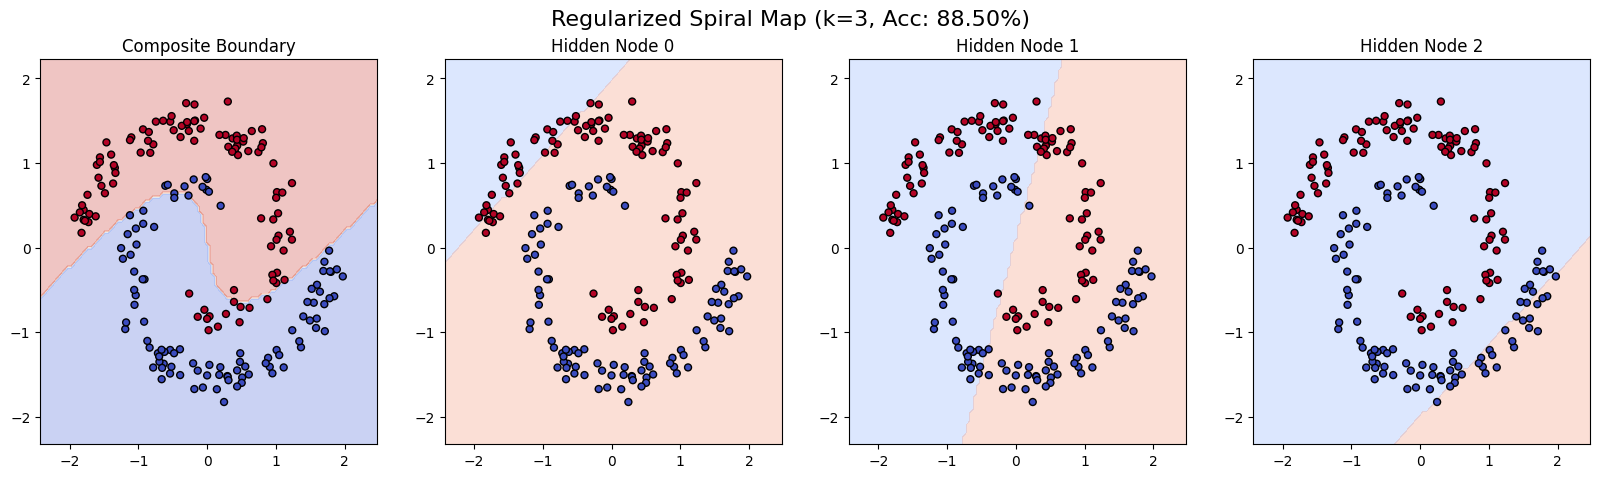

------------------------------
HYPERPARAMETERS (Regularized)
------------------------------
Dataset             : Spiral
Learning Rate       : 0.1
Epochs              : 5000
Hidden Nodes (k)    : 3
Orthogonality Lambda: 0.01
Optimizer           : Gradient Descent
Loss                : Multi-class(2 classes) CrossEntropy + Penalty
------------------------------



In [41]:
""" Spiral Dataset with k = 3 and Multi-class Classification using Cross-Entropy Loss + Orthogonality Penalty """

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# standard seed for the whole project
torch.manual_seed(42)
np.random.seed(42)

# --- Orthogonality Helper ---
def compute_ortho_penalty(net):
    # Pull weights from the first layer
    W = net[0].weight # Shape (hidden_nodes, input_dim)
    
    # Calculate dot product matrix
    dot_matrix = W @ W.t()
    
    # Isolate the off-diagonal elements
    diagonal_part = torch.diag(torch.diag(dot_matrix))
    off_diagonal = dot_matrix - diagonal_part
    
    # Return the sum of squares of off-diagonals
    return torch.sum(off_diagonal**2)

# --- Spiral Experiment Function ---
def spiral_ortho_experiment(penalty_weight, label_tag):
    # Load raw data
    df_train = pd.read_csv('spiral_train.csv')
    df_test = pd.read_csv('spiral_test.csv')
    
    # Extract features and targets
    x_train_raw = torch.tensor(df_train[['x1', 'x2']].values, dtype=torch.float32)
    train_targets = torch.tensor(df_train['label'].values, dtype=torch.long)
    
    x_test_raw = torch.tensor(df_test[['x1', 'x2']].values, dtype=torch.float32)
    test_targets = torch.tensor(df_test['label'].values, dtype=torch.long)

    # Manual normalization based on training stats
    avg = x_train_raw.mean(dim=0)
    std_dev = x_train_raw.std(dim=0)
    
    train_features = (x_train_raw - avg) / std_dev
    test_features = (x_test_raw - avg) / std_dev

    # MLP setup: 2 inputs -> 3 hidden (k=3) -> 2 output classes
    model = nn.Sequential(
        nn.Linear(2, 3),
        nn.Tanh(),
        nn.Linear(3, 2) 
    )
    
    optimizer = optim.SGD(model.parameters(), lr=0.1)
    loss_function = nn.CrossEntropyLoss()

    # Track loss history
    train_losses = []

    print(f"Training Spiral with {label_tag} (penalty={penalty_weight})...")
    
    # Training Loop
    for step in range(5000):
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(train_features)
        
        # Calculate MCE loss + the custom orthogonality penalty
        mce_loss = loss_function(predictions, train_targets)
        ortho_loss = compute_ortho_penalty(model)
        
        total_loss = mce_loss + penalty_weight * ortho_loss
        
        total_loss.backward()
        optimizer.step()
        
        train_losses.append(total_loss.item())

    # Evaluation on the test set
    model.eval()
    with torch.no_grad():
        test_logits = model(test_features)
        test_preds = torch.argmax(test_logits, dim=1)
        accuracy = (test_preds == test_targets).float().mean().item()
    
    print(f">> {label_tag} Results | Test Accuracy: {accuracy:.2%}")

    # --- LOSS CURVE PLOT ---
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Total Training Loss', color='#FF6B35')
    plt.title(f"Training Loss Curve: {label_tag}")
    plt.xlabel("Epoch (Step)")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- VISUALIZATION BLOCK ---
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    plt.suptitle(f"{label_tag} Spiral Map (k=3, Acc: {accuracy:.2%})", fontsize=16)
    
    # 1. Prepare grid for decision maps
    x0, x1 = test_features[:, 0].min() - 0.5, test_features[:, 0].max() + 0.5
    y0, y1 = test_features[:, 1].min() - 0.5, test_features[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x0, x1, 100), np.linspace(y0, y1, 100))
    grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    # 2. Plot Full Model Composite
    with torch.no_grad():
        Z_full = torch.argmax(model(grid_tensor), dim=1).reshape(xx.shape).numpy()
    
    axes[0].contourf(xx, yy, Z_full, alpha=0.3, cmap='coolwarm')
    axes[0].scatter(test_features[:, 0], test_features[:, 1], c=test_targets, cmap='coolwarm', edgecolors='k', s=25)
    axes[0].set_title("Composite Boundary")

    # 3. Plot Individual Hidden Nodes as Binary Classifiers
    W1 = model[0].weight.detach()
    b1 = model[0].bias.detach()
    
    for i in range(3):
        with torch.no_grad():
            node_activation = torch.tanh(grid_tensor @ W1[i] + b1[i]).reshape(xx.shape).numpy()
            
        axes[i+1].contourf(xx, yy, node_activation > 0, alpha=0.3, cmap='coolwarm')
        axes[i+1].scatter(test_features[:, 0], test_features[:, 1], c=test_targets, cmap='coolwarm', edgecolors='k', s=25)
        axes[i+1].set_title(f"Hidden Node {i}")

    plt.show()

    # --- HYPERPARAMETER DISPLAY ---
    hparams = {
        "Dataset": "Spiral",
        "Learning Rate": 0.1,
        "Epochs": 5000,
        "Hidden Nodes (k)": 3,
        "Orthogonality Lambda": penalty_weight,
        "Optimizer": "Gradient Descent",
        "Loss": "Multi-class(2 classes) CrossEntropy + Penalty"
    }
    print("-" * 30)
    print(f"HYPERPARAMETERS ({label_tag})")
    print("-" * 30)
    for k, v in hparams.items():
        print(f"{k:20}: {v}")
    print("-" * 30 + "\n")

# --- Execution ---
spiral_ortho_experiment(penalty_weight=0.0, label_tag="Unregularized")
spiral_ortho_experiment(penalty_weight=0.01, label_tag="Regularized")

When lambda was set higher at 1, accuracy dropped at k = 3 because the regularization started over-constraining the model. The regularizer dominated the learning signal, the model underfitted, and it couldn't bend the decision boundary enough to match the data. Hence, lambda of 0.01 gave much better accuracy. The Spiral dataset required more epochs (5000) even in the better-tuned setting for strong accuracy. The Xor dataset below only required 2000 though.

Training XOR with Unregularized (penalty=0.0)...
>> Unregularized Results | Test Accuracy: 85.00%


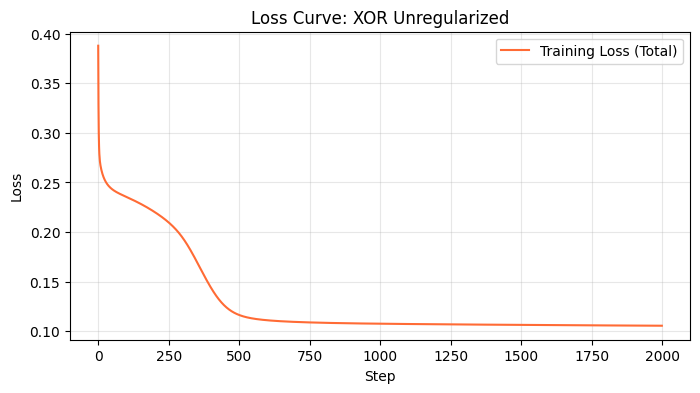

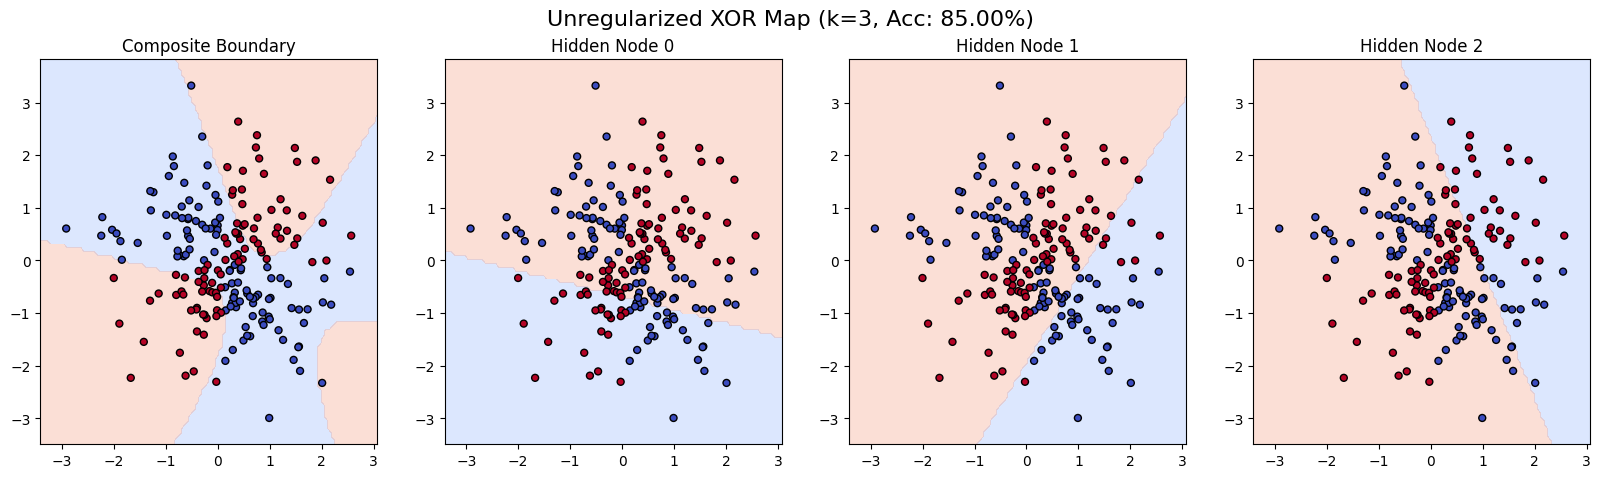

------------------------------
Experiment               : Unregularized
Learning Rate            : 0.1
Steps                    : 2000
Hidden Nodes (k)         : 3
Orthogonality Lambda     : 0.0
Loss Function            : MSELoss + Penalty
Optimizer                : Gradient Descent
------------------------------

Training XOR with Regularized (penalty=0.01)...
>> Regularized Results | Test Accuracy: 88.50%


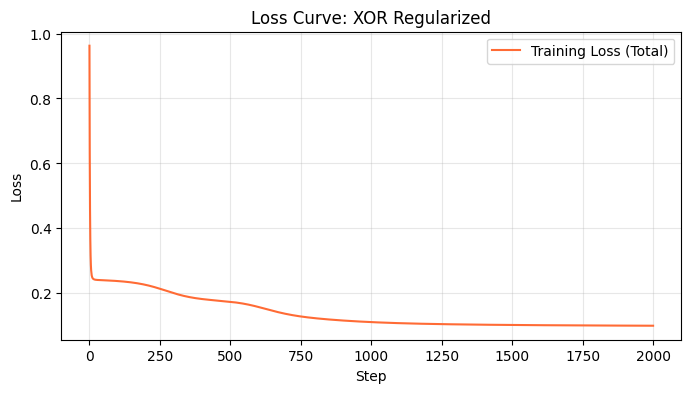

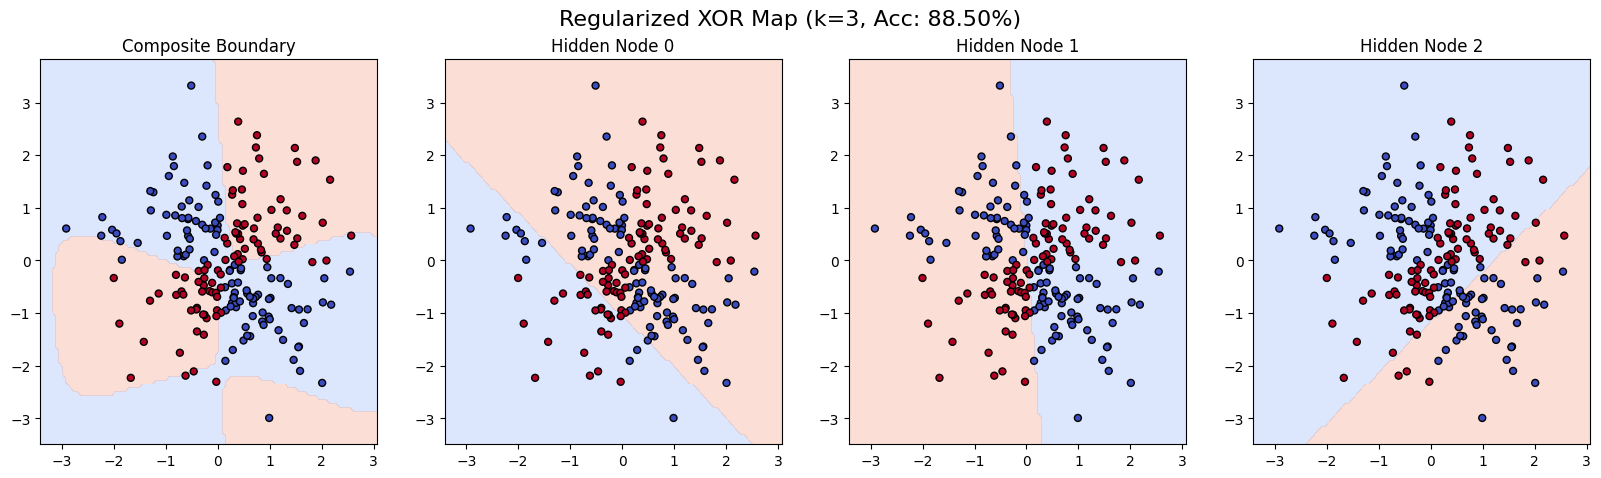

------------------------------
Experiment               : Regularized
Learning Rate            : 0.1
Steps                    : 2000
Hidden Nodes (k)         : 3
Orthogonality Lambda     : 0.01
Loss Function            : MSELoss + Penalty
Optimizer                : Gradient Descent
------------------------------



In [42]:
""" XOR Dataset with k = 3 and MSE Classification + Orthogonality Penalty """

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# standard seed
torch.manual_seed(42)
np.random.seed(42)

# --- Orthogonality Helper ---
def compute_ortho_penalty(net):
    # Pull weights from the first layer
    W = net[0].weight # Shape (hidden_nodes, input_dim)
    
    # Calculate dot product matrix
    dot_matrix = W @ W.t()
    
    # Isolate the off-diagonal elements
    diagonal_part = torch.diag(torch.diag(dot_matrix))
    off_diagonal = dot_matrix - diagonal_part
    
    # Return the sum of squares of off-diagonals
    return torch.sum(off_diagonal**2)

# --- XOR Experiment Function ---
def xor_ortho_experiment(penalty_weight, label_tag):
    # Load raw data
    df_train = pd.read_csv('xor_train.csv')
    df_test = pd.read_csv('xor_test.csv')
    
    # Extract features and targets
    x_train_raw = torch.tensor(df_train[['x1', 'x2']].values, dtype=torch.float32)
    # MSE requires float targets in shape (N, 1)
    train_targets = torch.tensor(df_train['label'].values, dtype=torch.float32).reshape(-1, 1)
    
    x_test_raw = torch.tensor(df_test[['x1', 'x2']].values, dtype=torch.float32)
    test_targets = torch.tensor(df_test['label'].values, dtype=torch.float32).reshape(-1, 1)

    # Manual normalization based on training stats
    avg = x_train_raw.mean(dim=0)
    std_dev = x_train_raw.std(dim=0)
    
    train_features = (x_train_raw - avg) / std_dev
    test_features = (x_test_raw - avg) / std_dev

    # MLP setup: 2 inputs -> 3 hidden (k=3) -> 1 output (MSE classification)
    model = nn.Sequential(
        nn.Linear(2, 3),
        nn.Tanh(),
        nn.Linear(3, 1) 
    )
    
    optimizer = optim.SGD(model.parameters(), lr=0.1)
    loss_function = nn.MSELoss()

    # Lists for curves
    train_losses = []

    print(f"Training XOR with {label_tag} (penalty={penalty_weight})...")
    
    # Training Loop
    for step in range(2000):
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(train_features)
        
        # Calculate MSE loss + the custom orthogonality penalty
        mse_loss = loss_function(predictions, train_targets)
        ortho_loss = compute_ortho_penalty(model)
        
        total_loss = mse_loss + penalty_weight * ortho_loss
        
        total_loss.backward()
        optimizer.step()
        
        train_losses.append(total_loss.item())

    # Evaluation on the test set
    model.eval()
    with torch.no_grad():
        test_out = model(test_features)
        # Threshold at 0.5 for binary classification
        test_preds = (test_out > 0.5).float()
        accuracy = (test_preds == test_targets).float().mean().item()
    
    print(f">> {label_tag} Results | Test Accuracy: {accuracy:.2%}")

    # --- LOSS CURVE PLOT ---
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Training Loss (Total)', color='#FF6B35')
    plt.title(f"Loss Curve: XOR {label_tag}")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- VISUALIZATION BLOCK ---
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    plt.suptitle(f"{label_tag} XOR Map (k=3, Acc: {accuracy:.2%})", fontsize=16)
    
    # 1. Prepare grid for decision maps
    x0, x1 = test_features[:, 0].min() - 0.5, test_features[:, 0].max() + 0.5
    y0, y1 = test_features[:, 1].min() - 0.5, test_features[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x0, x1, 100), np.linspace(y0, y1, 100))
    grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    # 2. Plot Full Model Composite
    with torch.no_grad():
        Z_full = (model(grid_tensor) > 0.5).reshape(xx.shape).numpy()
    
    axes[0].contourf(xx, yy, Z_full, alpha=0.3, cmap='coolwarm')
    axes[0].scatter(test_features[:, 0], test_features[:, 1], c=test_targets.flatten(), cmap='coolwarm', edgecolors='k', s=25)
    axes[0].set_title("Composite Boundary")

    # 3. Plot Individual Hidden Nodes as Binary Classifiers
    W1 = model[0].weight.detach()
    b1 = model[0].bias.detach()
    
    for i in range(3):
        with torch.no_grad():
            # Activation logic identical to Spiral code
            node_activation = torch.tanh(grid_tensor @ W1[i] + b1[i]).reshape(xx.shape).numpy()
            
        axes[i+1].contourf(xx, yy, node_activation > 0, alpha=0.3, cmap='coolwarm')
        axes[i+1].scatter(test_features[:, 0], test_features[:, 1], c=test_targets.flatten(), cmap='coolwarm', edgecolors='k', s=25)
        axes[i+1].set_title(f"Hidden Node {i}")

    plt.show()

    # --- HYPERPARAMETER DISPLAY ---
    config = {
        "Experiment": label_tag,
        "Learning Rate": 0.1,
        "Steps": 2000,
        "Hidden Nodes (k)": 3,
        "Orthogonality Lambda": penalty_weight,
        "Loss Function": "MSELoss + Penalty",
        "Optimizer": "Gradient Descent"
    }
    print("-" * 30)
    for k, v in config.items():
        print(f"{k:25}: {v}")
    print("-" * 30 + "\n")

# --- Execution ---
xor_ortho_experiment(penalty_weight=0.0, label_tag="Unregularized")
xor_ortho_experiment(penalty_weight=0.01, label_tag="Regularized")